In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
# === Config ===
train_csv = 'csv/train.csv'
val_csv = 'csv/val.csv'
test_csv = 'csv/test.csv'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# === Dataset ===
class SeasonDataset(Dataset):
    def __init__(self, csv_file, transform=None, label_encoder=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.le = label_encoder or LabelEncoder()
        self.data['label_encoded'] = self.le.fit_transform(self.data['label'])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = row['file_path'].replace("\\", "/")
        label = row['label_encoded']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

In [3]:
# === Transforms ===
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3)
])

# === Label Encoder Shared ===
all_labels = pd.read_csv(train_csv)['label'].tolist()
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)

# === Load Data ===
train_dataset = SeasonDataset(train_csv, transform, label_encoder)
val_dataset = SeasonDataset(val_csv, transform, label_encoder)
test_dataset = SeasonDataset(test_csv, transform, label_encoder)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

In [4]:
# === Model ===
model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
model.classifier = nn.Sequential(
    nn.Flatten(1),
    nn.LayerNorm(768, eps=1e-06),
    nn.Dropout(0.5),
    nn.Linear(768, len(label_encoder.classes_))
)
model = model.to(device)

# === Loss & Optimizer ===
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-5)

# === Scheduler with Warm-up ===
def warmup_lambda(epoch):
    return min(1.0, (epoch + 1) / 5)

scheduler = LambdaLR(optimizer, lr_lambda=warmup_lambda)

# === Train & Evaluate ===
def evaluate(model, dataloader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# === Training Loop ===
epochs = 30
patience = 5
best_val_acc = 0.0
epochs_no_improve = 0
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

In [5]:
print("Training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_losses.append(running_loss)
    train_accuracies.append(correct / total)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_losses.append(val_loss)
    val_accuracies.append(val_correct / val_total)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f}, Acc: {train_accuracies[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}, Acc: {val_accuracies[-1]:.4f}")

    if val_accuracies[-1] > best_val_acc:
        best_val_acc = val_accuracies[-1]
        os.makedirs("model", exist_ok=True)
        torch.save(model.state_dict(), "models/seasonal_model_best_convnexttiny.pth")
        print("Best model saved.")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")

    if epochs_no_improve >= patience:
        print("Early stopping triggered.")
        break

    scheduler.step()

Training...


100%|██████████| 62/62 [00:26<00:00,  2.34it/s]


Epoch 1/30 | Train Loss: 148.2727, Acc: 0.1763 | Val Loss: 14.5558, Acc: 0.3923
Best model saved.


100%|██████████| 62/62 [00:26<00:00,  2.35it/s]


Epoch 2/30 | Train Loss: 101.0355, Acc: 0.4342 | Val Loss: 8.5991, Acc: 0.6423
Best model saved.


...

Epoch 13/30 | Train Loss: 9.2995, Acc: 0.9550 | Val Loss: 6.9308, Acc: 0.7459
No improvement for 3 epoch(s)


100%|██████████| 62/62 [00:25<00:00,  2.46it/s]


Epoch 14/30 | Train Loss: 7.5294, Acc: 0.9657 | Val Loss: 7.3579, Acc: 0.7500
No improvement for 4 epoch(s)


100%|██████████| 62/62 [00:24<00:00,  2.48it/s]


Epoch 15/30 | Train Loss: 6.2131, Acc: 0.9743 | Val Loss: 7.7109, Acc: 0.7480
No improvement for 5 epoch(s)
Early stopping triggered.


Test Accuracy: 0.7459


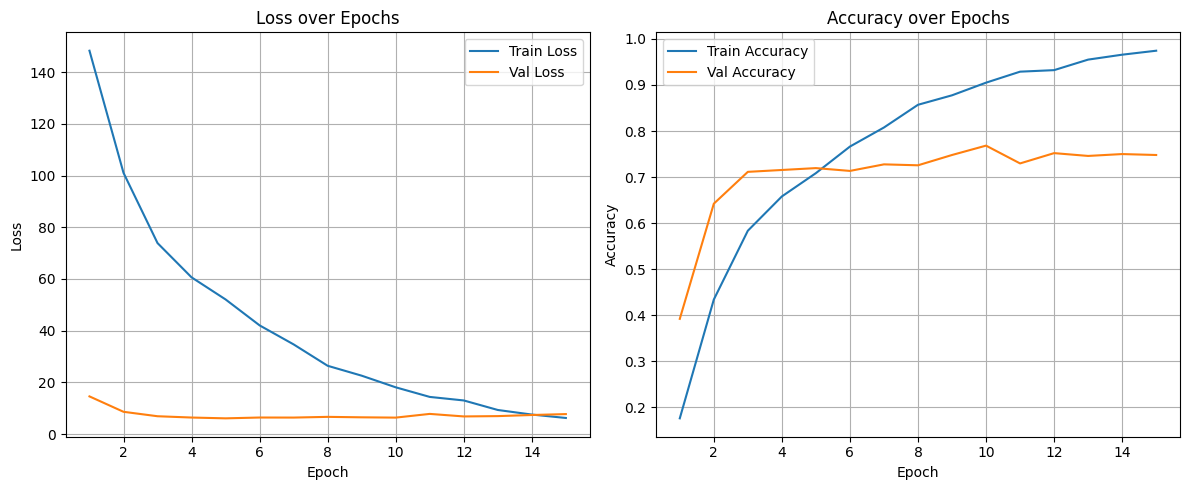

In [6]:
model.load_state_dict(torch.load("models/seasonal_model_best_convnexttiny.pth"))
model.eval()

test_acc = evaluate(model, test_loader)
print(f"Test Accuracy: {test_acc:.4f}")

# === Metrics Plot ===
epochs_range = range(1, len(train_losses) + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

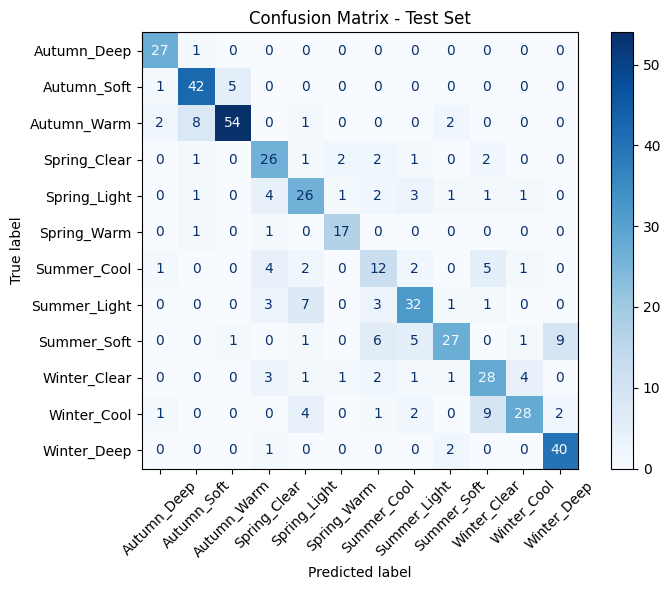


Classification Report:

              precision    recall  f1-score   support

 Autumn_Deep       0.84      0.96      0.90        28
 Autumn_Soft       0.78      0.88      0.82        48
 Autumn_Warm       0.90      0.81      0.85        67
Spring_Clear       0.62      0.74      0.68        35
Spring_Light       0.60      0.65      0.63        40
 Spring_Warm       0.81      0.89      0.85        19
 Summer_Cool       0.43      0.44      0.44        27
Summer_Light       0.70      0.68      0.69        47
 Summer_Soft       0.79      0.54      0.64        50
Winter_Clear       0.61      0.68      0.64        41
 Winter_Cool       0.80      0.60      0.68        47
 Winter_Deep       0.78      0.93      0.85        43

    accuracy                           0.73       492
   macro avg       0.72      0.73      0.72       492
weighted avg       0.74      0.73      0.73       492



In [7]:
# === Confusion Matrix ===
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

In [8]:
from PIL import Image

def predict_image(image_path):
    # Load and preprocess the image
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)  # Add batch dimension

    # Load trained model (only once if in loop)
    model.load_state_dict(torch.load("models/seasonal_model_best_convnexttiny.pth", map_location=device))
    model.to(device)
    model.eval()

    # Inference
    with torch.no_grad():
        output = model(image)
        pred_idx = output.argmax(dim=1).item()
        label = label_encoder.inverse_transform([pred_idx])[0]

    print(f"Predicted Seasonal Tone: {label}")
    return label

# === Example usage ===
predict_image("clustered_seasons_kmeans/Winter/Deep/14311.png")


Predicted Seasonal Tone: Winter_Deep


'Winter_Deep'